In [53]:
import pandas as pd

df = pd.read_csv("../data/processed/features_completas_por_circuito.csv")

corr = df.drop(columns=["circuito"]).corr()
corr.round(2)

,vel_media,vel_minima,zonas_freio,pico_desac,densidade_curvas,abrasion,pit_lane_time_loss_s,altitude_m
vel_media,1.00,0.49,-0.73,0.09,-0.72,0.28,-0.01,-0.10
vel_minima,0.49,1.00,-0.22,0.46,-0.24,0.06,0.27,-0.16
zonas_freio,-0.73,-0.22,1.00,0.13,0.59,-0.26,0.33,-0.05
pico_desac,0.09,0.46,0.13,1.00,0.04,0.16,0.31,-0.11
densidade_curvas,-0.72,-0.24,0.59,0.04,1.00,-0.36,-0.02,-0.02
abrasion,0.28,0.06,-0.26,0.16,-0.36,1.00,0.29,-0.06
pit_lane_time_loss_s,-0.01,0.27,0.33,0.31,-0.02,0.29,1.00,-0.10
altitude_m,-0.10,-0.16,-0.05,-0.11,-0.02,-0.06,-0.10,1.00


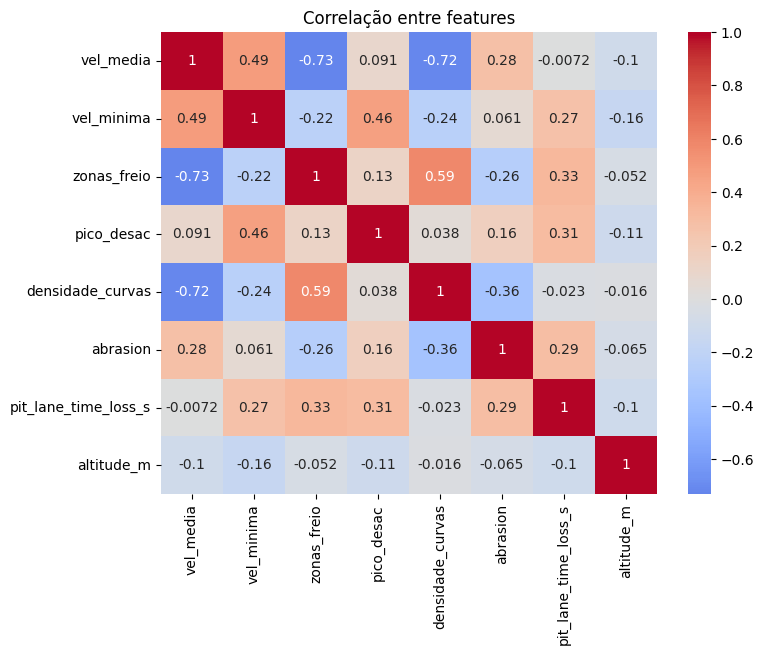

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre features")
plt.show()

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=["circuito"])

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_std)

pca.explained_variance_ratio_

array([0.34239656, 0.22603693, 0.13289132, 0.1169    , 0.08065256,
       0.04924938, 0.03282256, 0.0190507 ])

In [56]:
import pandas as pd

pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"]
)

pca_df["circuito"] = df["circuito"]

pca_df.head()

,PC1,PC2,circuito
0,-0.680987,-0.194856,Austin
1,-1.552632,-0.545485,Baku
2,0.810852,0.583201,Barcelona
3,-1.052205,0.696505,Budapest
4,0.872185,2.225366,Imola


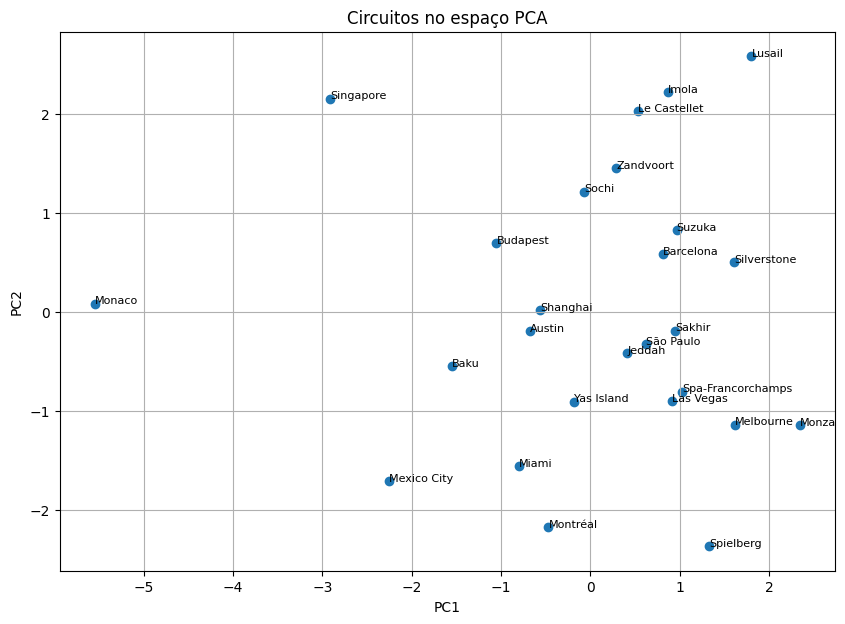

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(pca_df["PC1"], pca_df["PC2"])

for _, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["circuito"], fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Circuitos no espaço PCA")
plt.grid(True)
plt.show()

In [58]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(X.columns))],
    index=X.columns
)

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
vel_media,0.557,-0.072,-0.137,-0.003,-0.140,-0.039,-0.296,0.746
vel_minima,0.340,0.379,-0.441,0.226,-0.181,0.462,0.486,-0.114
zonas_freio,-0.472,0.347,0.088,-0.011,-0.188,-0.295,0.482,0.542
pico_desac,0.113,0.551,-0.192,0.281,0.585,-0.423,-0.208,-0.060
densidade_curvas,-0.495,0.146,-0.181,0.002,0.254,0.642,-0.381,0.280
abrasion,0.295,0.156,0.685,-0.178,0.445,0.316,0.272,0.128
pit_lane_time_loss_s,0.040,0.564,0.398,0.039,-0.554,0.057,-0.426,-0.173
altitude_m,-0.065,-0.253,0.285,0.915,-0.028,0.069,0.020,0.087


In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

resultados_k = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = kmeans.fit_predict(X_std)
    silhouette = silhouette_score(X_std, labels)
    
    resultados_k.append({
        "k": k,
        "silhouette": silhouette
    })

resultados_k = pd.DataFrame(resultados_k)
resultados_k

,k,silhouette
0,2,0.374505
1,3,0.148237
2,4,0.158549
3,5,0.140507
4,6,0.128235
5,7,0.175094
6,8,0.177685


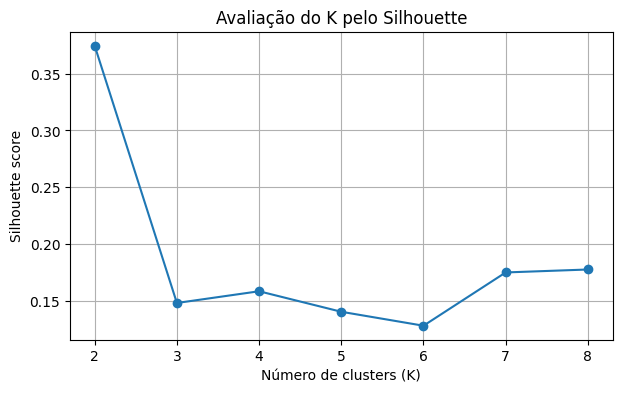

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(resultados_k["k"], resultados_k["silhouette"], marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette score")
plt.title("Avaliação do K pelo Silhouette")
plt.grid(True)
plt.show()

In [61]:
k_escolhido = 3

kmeans = KMeans(
    n_clusters=k_escolhido,
    random_state=42,
    n_init=50
)

df_cluster = df.copy()
df_cluster["cluster"] = kmeans.fit_predict(X_std)

df_cluster.sort_values("cluster")

,circuito,vel_media,vel_minima,zonas_freio,pico_desac,densidade_curvas,abrasion,pit_lane_time_loss_s,altitude_m,cluster
0,Austin,208.869565,82.000,10.0,-32.870370,3.627789,3.5,20.6,130,0
1,Baku,209.581267,80.220,11.0,-32.543003,3.331667,1.0,19.7,-25,0
6,Las Vegas,234.515557,91.000,8.0,-31.046131,2.741493,2.0,20.0,610,0
5,Jeddah,247.838906,95.660,8.0,-31.435185,4.373178,2.0,19.2,12,0
13,Montréal,214.919414,66.880,7.0,-33.854167,3.210273,1.5,18.4,13,0
14,Monza,258.066465,75.000,7.0,-34.305556,1.898843,3.0,24.3,142,0
11,Miami,219.570962,73.840,9.0,-35.879630,3.510717,2.0,19.9,1,0
9,Melbourne,241.278146,98.700,7.0,-33.142361,2.652520,2.0,19.3,10,0
15,Sakhir,215.238814,74.440,8.0,-32.756197,2.771619,5.0,22.9,-16,0
21,Spielberg,239.189591,75.040,7.0,-35.833333,2.315887,3.0,20.3,721,0


In [62]:
df_cluster.groupby("cluster")["circuito"].apply(list)

cluster
0    [Austin, Baku, Jeddah, Las Vegas, Melbourne, M...
1                     [Mexico City, Monaco, Singapore]
2    [Barcelona, Budapest, Imola, Le Castellet, Lus...
Name: circuito, dtype: object

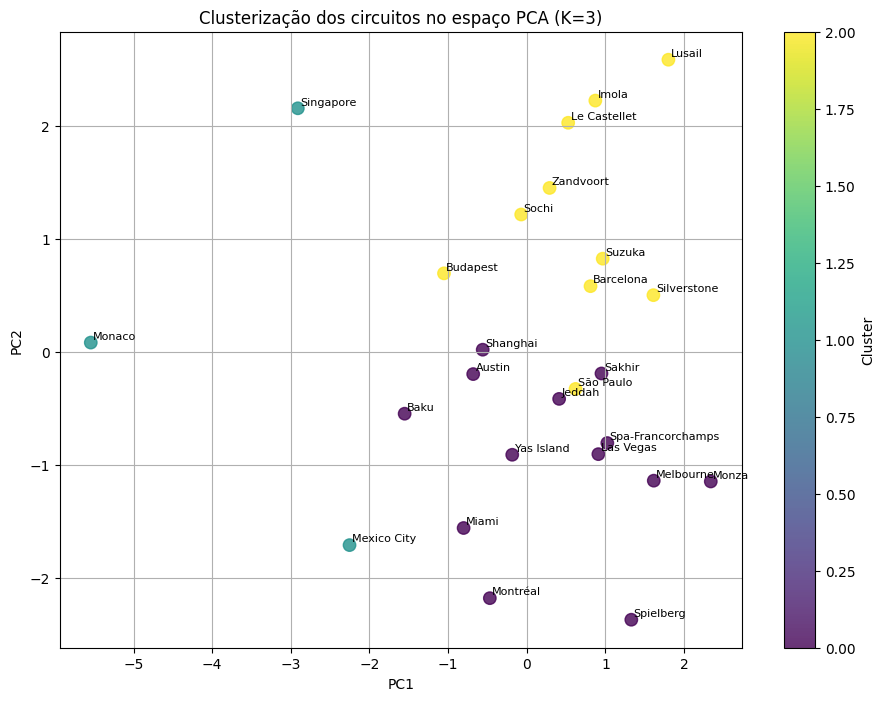

In [63]:
import matplotlib.pyplot as plt

# adiciona o cluster ao dataframe do PCA
pca_df["cluster"] = df_cluster["cluster"]

plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    s=80,
    alpha=0.8
)

for _, row in pca_df.iterrows():
    plt.text(
        row["PC1"] + 0.03,
        row["PC2"] + 0.03,
        row["circuito"],
        fontsize=8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Clusterização dos circuitos no espaço PCA (K={k_escolhido})")
plt.grid(True)
plt.colorbar(scatter, label="Cluster")
plt.show()

In [65]:
feature_sets = {
    "todas": [
        "vel_media", "vel_minima", "zonas_freio", "pico_desac",
        "densidade_curvas", "abrasion", "pit_lane_time_loss_s", "altitude_m"
    ],
    "sem_altitude": [
        "vel_media", "vel_minima", "zonas_freio", "pico_desac",
        "densidade_curvas", "abrasion", "pit_lane_time_loss_s"
    ],
    "sem_pit_altitude": [
        "vel_media", "vel_minima", "zonas_freio", "pico_desac",
        "densidade_curvas", "abrasion"
    ],
    "so_dinamicas": [
        "vel_media", "vel_minima", "zonas_freio", "pico_desac", "densidade_curvas"
    ],
}

In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

resultados = []

for nome, features in feature_sets.items():
    X = df[features]
    X_std = StandardScaler().fit_transform(X)

    for k in range(2, 7):
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=50
        )

        labels = kmeans.fit_predict(X_std)
        sil = silhouette_score(X_std, labels)

        resultados.append({
            "feature_set": nome,
            "k": k,
            "silhouette": sil
        })

resultados = pd.DataFrame(resultados)
resultados.sort_values(["feature_set", "k"])

,feature_set,k,silhouette
5,sem_altitude,2,0.190284
6,sem_altitude,3,0.167580
7,sem_altitude,4,0.171825
8,sem_altitude,5,0.186267
9,sem_altitude,6,0.170864
10,sem_pit_altitude,2,0.222199
11,sem_pit_altitude,3,0.209869
12,sem_pit_altitude,4,0.215200
13,sem_pit_altitude,5,0.199616
14,sem_pit_altitude,6,0.198454


In [67]:
resultados.loc[
    resultados.groupby("feature_set")["silhouette"].idxmax()
].sort_values("silhouette", ascending=False)

,feature_set,k,silhouette
15,so_dinamicas,2,0.378871
0,todas,2,0.374505
10,sem_pit_altitude,2,0.222199
5,sem_altitude,2,0.190284


In [93]:
features = feature_sets["so_dinamicas"]
k_escolhido = 4

X = df[features]
X_std = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=k_escolhido,
    random_state=42,
    n_init=50
)

df_cluster = df.copy()
df_cluster["cluster"] = kmeans.fit_predict(X_std)

df_cluster.groupby("cluster")["circuito"].apply(list)

cluster
0    [Barcelona, Budapest, Imola, Jeddah, Le Castel...
1    [Austin, Baku, Mexico City, Miami, Montréal, S...
2    [Las Vegas, Melbourne, Monza, Spa-Francorchamp...
3                                  [Monaco, Singapore]
Name: circuito, dtype: object

In [94]:
cluster_profile = (
    df_cluster
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

cluster_profile

,vel_media,vel_minima,zonas_freio,pico_desac,densidade_curvas
cluster,,,,,
0,227.64,96.18,9.09,-28.67,3.35
1,212.55,73.92,9.12,-33.45,3.39
2,242.44,82.35,7.60,-32.84,2.46
3,178.09,61.14,13.00,-30.95,5.18


In [96]:
for c in sorted(df_cluster["cluster"].unique()):
    print(f"\nCLUSTER {c}")
    print(
        sorted(
            df_cluster[
                df_cluster["cluster"] == c
            ]["circuito"].tolist()
        )
    )


CLUSTER 0
['Barcelona', 'Budapest', 'Imola', 'Jeddah', 'Le Castellet', 'Lusail', 'Silverstone', 'Sochi', 'Suzuka', 'São Paulo', 'Zandvoort']

CLUSTER 1
['Austin', 'Baku', 'Mexico City', 'Miami', 'Montréal', 'Sakhir', 'Shanghai', 'Yas Island']

CLUSTER 2
['Las Vegas', 'Melbourne', 'Monza', 'Spa-Francorchamps', 'Spielberg']

CLUSTER 3
['Monaco', 'Singapore']


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
 
# Mesmo conjunto e padronização do k-means (conjunto dinâmico + densidade)
features = ["vel_media", "vel_minima", "zonas_freio", "pico_desac", "densidade_curvas"]
X = StandardScaler().fit_transform(df[features])
 
# Matriz de ligação (a árvore inteira)
Z = linkage(X, method="ward")
 
# Quão bem a árvore representa as distâncias originais (>0.7 = boa)
coph, _ = cophenet(Z, pdist(X))
print(f"Correlação cofenética: {coph:.3f}")

Correlação cofenética: 0.667


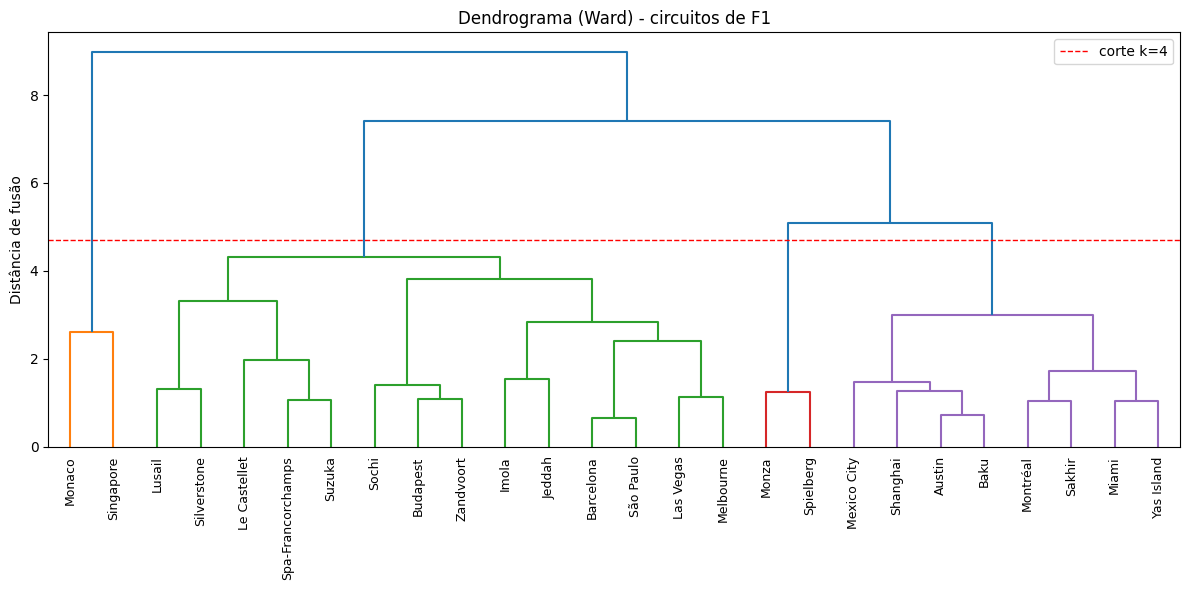

In [72]:
plt.figure(figsize=(12, 6))
dendrogram(
    Z,
    labels=df["circuito"].values,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=Z[-3, 2],  # destaca os 4 grupos
)
# linha de corte que produz 4 clusters (entre a 3a e a 4a maior fusão)
corte = (Z[-3, 2] + Z[-4, 2]) / 2
plt.axhline(corte, color="red", ls="--", lw=1, label=f"corte k=4")
plt.title("Dendrograma (Ward) - circuitos de F1")
plt.ylabel("Distância de fusão")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
df["cluster_hier"] = fcluster(Z, t=4, criterion="maxclust")
 
for c in sorted(df["cluster_hier"].unique()):
    print(f"\nCLUSTER {c}")
    print(sorted(df[df["cluster_hier"] == c]["circuito"].tolist()))


CLUSTER 1
['Monaco', 'Singapore']

CLUSTER 2
['Barcelona', 'Budapest', 'Imola', 'Jeddah', 'Las Vegas', 'Le Castellet', 'Lusail', 'Melbourne', 'Silverstone', 'Sochi', 'Spa-Francorchamps', 'Suzuka', 'São Paulo', 'Zandvoort']

CLUSTER 3
['Monza', 'Spielberg']

CLUSTER 4
['Austin', 'Baku', 'Mexico City', 'Miami', 'Montréal', 'Sakhir', 'Shanghai', 'Yas Island']


In [74]:
df.groupby("cluster_hier")[features].mean().round(2)

,vel_media,vel_minima,zonas_freio,pico_desac,densidade_curvas
cluster_hier,,,,,
1,178.09,61.14,13.00,-30.95,5.18
2,229.92,94.26,8.86,-29.25,3.21
3,248.63,75.02,7.00,-35.07,2.11
4,212.55,73.92,9.12,-33.45,3.39


In [76]:
from itertools import permutations
 
a = df_cluster["cluster"].to_numpy()         # k-means
b = df["cluster_hier"].to_numpy() - 1  # Ward (fcluster começa em 1)
 
# alinha rótulos por melhor permutação (rótulos de cluster são arbitrários)
concord = max(
    np.mean([{i: p[i] for i in range(4)}[x] == y for x, y in zip(a, b)])
    for p in permutations(range(4))
)
print(f"Concordância k-means x Ward: {concord*100:.0f}%")

Concordância k-means x Ward: 88%
